Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Logistic Regression ---
Accuracy: 0.7650816181689141
Precision: 0.5381818181818182
Recall: 0.7935656836461126
F1-score: 0.6413867822318526
ROC-AUC: 0.7741959692361837




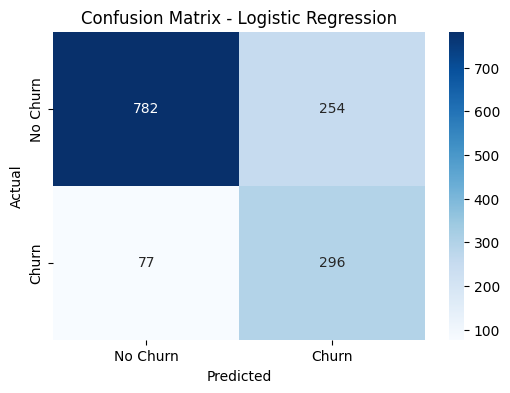

--- Random Forest ---
Accuracy: 0.794180269694819
Precision: 0.6426116838487973
Recall: 0.5013404825737265
F1-score: 0.5632530120481928
ROC-AUC: 0.700477191093813




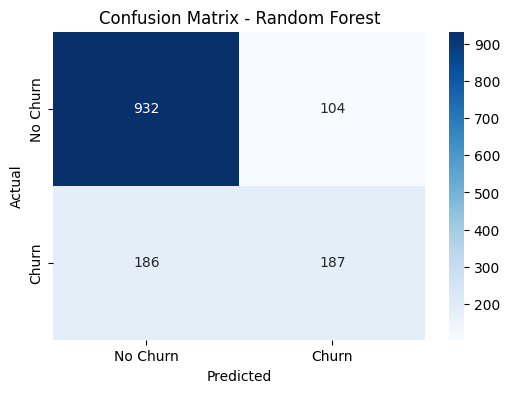

--- XGBoost ---
Accuracy: 0.7920511000709723
Precision: 0.6142857142857143
Recall: 0.5764075067024129
F1-score: 0.5947441217150761
ROC-AUC: 0.7230493131967664




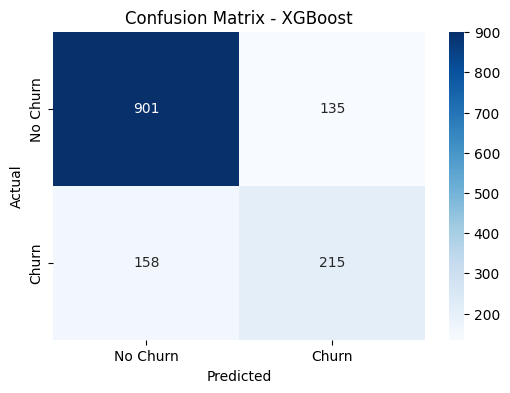

In [2]:
!pip install xgboost
!pip install imblearn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Preprocess Cleaned Data
# Assuming your cleaned data is in 'cleaned_telco_churn_data.csv'
df = pd.read_csv('cleaned_telco_churn_data.csv') 

# Convert 'Churn' to binary (0/1)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Handle categorical features using one-hot encoding
categorical_features = X.select_dtypes(include=['object', 'category']).columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(X[categorical_features])
feature_names = encoder.get_feature_names_out(categorical_features)
encoded_df = pd.DataFrame(encoded_features, columns=feature_names)

X = X.drop(categorical_features, axis=1)
X = pd.concat([X, encoded_df], axis=1)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# 4. Standardize Numerical Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Model Training and Prediction
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

predictions = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions[model_name] = model.predict(X_test)

# 6. Model Evaluation
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print("\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn', 'Churn'], 
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

for model_name, y_pred in predictions.items():
    evaluate_model(y_test, y_pred, model_name)

In [3]:
# Assuming 'df' is your cleaned DataFrame

# Save the DataFrame to a CSV file
df.to_csv('cleaned_telco_churn_data_for_powerbi.csv', index=False) 

# Import the necessary library for downloading files
from IPython.display import FileLink

# Create a download link for the CSV file
display(FileLink('cleaned_telco_churn_data_for_powerbi.csv'))

C:\Users\raish\OneDrive\Desktop\Masai\telco_customer\cleaned_telco_churn_data_for_powerbi.csv